[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EelcoHoogendoorn/numga/blob/rewrite/rewrite/examples/electromagnetism/constitutive/constitutive.ipynb) [![Open in GitHub Codespaces](https://github.com/codespaces/badge.svg)](https://codespaces.new/EelcoHoogendoorn/numga?ref=rewrite)

# Electromagnetic Constitutive Maps, Birefringence & Fresnel Drag in Spacetime Algebra

In a medium, Maxwell's equations split into the field bivector $F$ and the excitation bivector $G$, related by a linear map $G = \chi(F)$.

In Geometric Algebra, a linear map between multivector spaces is called an **extensor** (or outermorphism). In NumGA, leaving a blade subspace open in an expression compiles an extensor without writing coordinate matrices.
Here, $\chi$ is a **bivector-to-bivector extensor**: observer projectors compile isotropic glass, spatial quadrics compile birefringent crystals and ferrites, and Lorentz boost rotors produce moving media. Plane waves exist where the extensor wave map $a \mapsto k \cdot \chi(k \wedge a)$ loses rank, resolving birefringence, polarization eigenmodes, and relativistic Fresnel drag.


In [1]:
# Setup environment: clone repository and install dependencies if running in Colab
import sys
from pathlib import Path

if "google.colab" in sys.modules:
    import os, shutil, subprocess
    os.chdir("/content")  # Always reset to /content
    repo_dir = Path("/content/numga_repo")
    if not repo_dir.exists():
        subprocess.run(["git", "clone", "--depth", "1", "-b", "rewrite", "https://github.com/EelcoHoogendoorn/numga.git", str(repo_dir)], check=True)
    else:
        subprocess.run(["git", "-C", str(repo_dir), "pull", "origin", "rewrite"], check=False)
        for mod in list(sys.modules.keys()):
            if mod.startswith("examples") or mod.startswith("numga"):
                del sys.modules[mod]
    rewrite_dir = repo_dir / "rewrite"
    src_dir = rewrite_dir / "src"
    for p in [str(src_dir), str(rewrite_dir)]:
        if p not in sys.path:
            sys.path.insert(0, p)

# Ensure rewrite root is in sys.path when running locally:
for cand in [Path.cwd(), *Path.cwd().parents]:
    if (cand / "examples" / "electromagnetism" / "constitutive").is_dir():
        if str(cand) not in sys.path:
            sys.path.insert(0, str(cand))
        if str(cand / "src") not in sys.path:
            sys.path.insert(0, str(cand / "src"))
        break
    if (cand / "rewrite" / "examples" / "electromagnetism" / "constitutive").is_dir():
        p = str(cand / "rewrite")
        if p not in sys.path:
            sys.path.insert(0, p)
        if str(cand / "rewrite" / "src") not in sys.path:
            sys.path.insert(0, str(cand / "rewrite" / "src"))
        break


In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt

from numga import NumpyContext
from numga.algebras import STA
from examples.electromagnetism.constitutive import render

# Bind Spacetime Algebra STA: R_{1,3} with signature (t+, x-, y-, z-):
ctx = NumpyContext(STA)
mv = ctx.multivector

# Blade Subspaces:
Scalar = STA.gatype.scalar()                 # Grade 0: scalar real values
Vector = STA.gatype.vector()                 # Grade 1: spacetime vectors (t, x, y, z)
Bivector = STA.gatype.bivector()             # Grade 2: electromagnetic fields (E, B)
Spatial = STA.subspace("x y z")              # Polarizations in temporal gauge a · t = 0

# Extensors (linear maps between blade subspaces):
Constitutive = STA.gatype((Bivector, Bivector))  # Bivector <- Bivector
Permittivity = STA.gatype((Vector, Vector))      # Vector <- Vector

# Canonical Spacetime Basis:
t, x, y, z = mv.vector(np.eye(4))

## 1. The Observer, Media & Extensor Constitutive Relations

In Spacetime Algebra, an observer's 4-velocity $t$ decomposes 6D field bivectors into rest-frame electric ($F \cdot t$) and magnetic ($(I F) \cdot t$) vectors.
Material relations $\mathbf{D} = \boldsymbol{\epsilon}\mathbf{E}$ and $\mathbf{H} = \boldsymbol{\mu}^{-1}\mathbf{B}$ lift these 3D vector maps into 6D bivector extensors $G = \chi(F)$.\n

In [3]:
# 1. Observer projectors: split 6D field bivectors into electric and magnetic parts
#    In standard GA, an observer with 4-velocity t measures electric field E = F · t.
#    In NumGA, leaving the input subspace placeholder 'Bivector' open compiles an extensor (linear map):
#      - Bivector.commutator(t) maps any field F to its electric vector E = F · t = 1/2(F t - t F).
#      - .wedge(t) maps that vector E to the timelike bivector E ^ t.
#    The result is an idempotent extensor Pi_E: Bivector <- Bivector projecting F onto its electric part.
#    Subtracting from the identity extensor 'Bivector' yields the complementary magnetic projector Pi_B:
electric = Bivector.commutator(t).wedge(t)                                      # [] Bivector <- Bivector (Pi_E)
magnetic = Bivector - electric                                                  # [] Bivector <- Bivector (Pi_B)

# 2. Isotropic glass: G = eps * Pi_E(F) + (1/mu) * Pi_B(F)
#    In rest frame, Maxwell's excitation is G = D ^ t - I*H with D = eps*E and H = (1/mu)*B.
#    Because extensors are linear maps, we scale and add the projectors directly:
eps, mu = 2.25, 1.0
glass = eps * electric + (1.0 / mu) * magnetic                                  # [] Bivector <- Bivector

# 3. Anisotropic crystal: lifts a 3D permittivity quadric through the observer
#    In a birefringent crystal, D = eps · E is direction-dependent along lattice axes.
#    How do we build this as an extensor without coordinates?
#    - In STA (t+ x- y- z-), spatial basis vectors square to -1 (x^2 = -1), so -(x | Vector) * x
#      is the coordinate-free orthogonal projection of any vector onto the x-axis.
#    - Summing over axes builds a 3D symmetric linear map 'permittivity' (Vector <- Vector).
#    - Extensors compose like functions: Bivector.commutator(t) extracts E = F · t,
#      permittivity(...) polarizes it into D = eps(E), and .wedge(t) lifts D to timelike bivector D ^ t.
#    - Adding (1/mu) * magnetic retains the isotropic magnetic response:
permittivity = -(
    2.25 * x * (x | Vector) +
    1.5 * y * (y | Vector) +
    1.5 * z * (z | Vector)
)                                                                               # [] Vector <- Vector
crystal = permittivity(Bivector.commutator(t)).wedge(t) + (1.0 / mu) * magnetic # [] Bivector <- Bivector

# 4. Magnetic ferrite: lifts inverse permeability through the dual field
#    In anisotropic magnetic materials (e.g. biased ferrites), H = mu^{-1} · B varies by axis.
#    How do we isolate the magnetic field B in STA?
#    - The pseudoscalar dual (Bivector.dual(), F -> I*F) swaps electric and magnetic bivectors.
#      Taking the commutator with t then extracts the magnetic flux vector B = (I*F) · t!
#    - permeability_inv(...) maps vector B to the magnetizing vector H = mu^{-1}(B).
#    - .wedge(t) lifts H to timelike bivector H ^ t.
#    - .dual_inverse() applies -I(H ^ t), converting it to the spacelike excitation bivector -I*H.
#    - Adding eps * electric retains the isotropic electric response:
permeability_inv = -(
    1.0 * x * (x | Vector) +
    0.5 * y * (y | Vector) +
    1.0 * z * (z | Vector)
)                                                                               # [] Vector <- Vector
ferrite = (
    eps * electric +
    permeability_inv(Bivector.dual().commutator(t)).wedge(t).dual_inverse()
)                                                                               # [] Bivector <- Bivector

print("Electric projector extensor:", electric.gatype, f"({electric.structural_shape} kernel)")

Electric projector extensor: GAType(subspaces=(SubSpace(algebra=Algebra('t+x-y-z-'), masks=(3, 5, 6, 9, 10, 12), signs=(1, 1, 1, 1, 1, 1)), SubSpace(algebra=Algebra('t+x-y-z-'), masks=(3, 5, 6, 9, 10, 12), signs=(1, 1, 1, 1, 1, 1))), traits=TraitSet()) ((6, 6) kernel)


## 2. The 1D Dispersion Scan: Detecting Waves via Singular Values

A plane wave with wavevector $k = \omega t + \mathbf{k}$ has field $F = k \wedge a$. Maxwell's source-free equation in medium requires $k \cdot \chi(k \wedge a) = 0$.
The linear wave map $W_k: a \mapsto k \cdot \chi(k \wedge a)$ maps spatial polarization $a$ to vector. Physical waves exist precisely where $W_k$ loses rank ($\sigma_{\min} = 0$).
Scanning trial phase speed $v = \omega / |\mathbf{k}|$ along $\hat{\mathbf{z}}$ reveals resonance notches at the allowed propagation speeds.


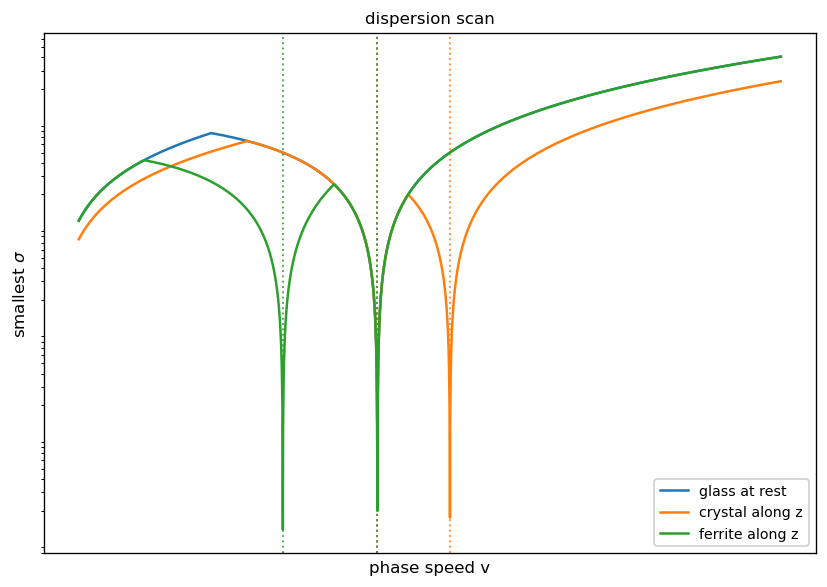

In [4]:
# 1. Sample trial phase speeds v = omega / |k|:
speeds = np.linspace(0.05, 1.5, 3001)

# 2. Wavevector k = v*t + z for propagation along the z-axis:
#    NumGA broadcasts NumPy array speeds directly against basis vector t:
k = speeds * t + z                                                            # [n_speeds] Vector

# 3. Wave map extensor W_k: a -> k · chi(k ^ a) mapping spatial polarizations to spacetime vectors:
#    - k.wedge(Spatial): for trial polarization vector a, forms field bivector F = k ^ a.
#    - medium(...): feeds F into constitutive extensor to produce excitation G = chi(F).
#    - k.commutator(...): evaluates Maxwell curl k · G = 0 on the excitation.
#    NumGA compiles this chain into a single linear map W_k: Vector <- Spatial.
#    Where its smallest singular value drops to zero, a non-trivial physical plane wave propagates:
media = {
    "glass at rest": glass,
    "crystal along z": crystal,
    "ferrite along z": ferrite,
}

curves = {}
for name, medium in media.items():
    wave = k.commutator(medium(k.wedge(Spatial)))                             # [n_speeds] Extensor: Vector <- Spatial
    curves[name] = wave.svdvals()[..., -1]

refractive_index = np.sqrt(eps * mu)
expected = {
    "glass at rest": [1.0 / refractive_index],
    "crystal along z": [1.0 / np.sqrt(2.25), 1.0 / np.sqrt(1.5)],
    "ferrite along z": [1.0 / np.sqrt(2.25 * 2.0), 1.0 / np.sqrt(2.25)],
}

# Plot 1: 1D dispersion resonance scan along z across media
fig = render.draw_dispersion_figure(speeds, curves, expected)
plt.show()

## 3. Physical Eigenmodes: Transverse Polarizations & Birefringence

At each resonance notch, who is oscillating?
Taking the SVD of the wave map $W_k$ at the allowed speeds, the right singular vector associated with $\sigma_{\min} = 0$ is the exact physical polarization state $a \in \mathbb{R}^3$.
For propagation along $\hat{\mathbf{z}}$, the crystal's slow and fast waves decouple into orthogonal linear polarizations along the principal axes $\hat{\mathbf{x}}$ and $\hat{\mathbf{y}}$.

In an isotropic medium (glass), both polarization components travel at the identical phase speed $v_{\text{slow}}$, maintaining an invariant linear polarization state. In the birefringent crystal, the phase slip $(k_x - k_y) z$ causes continuous polarization precession into an elliptical helix.


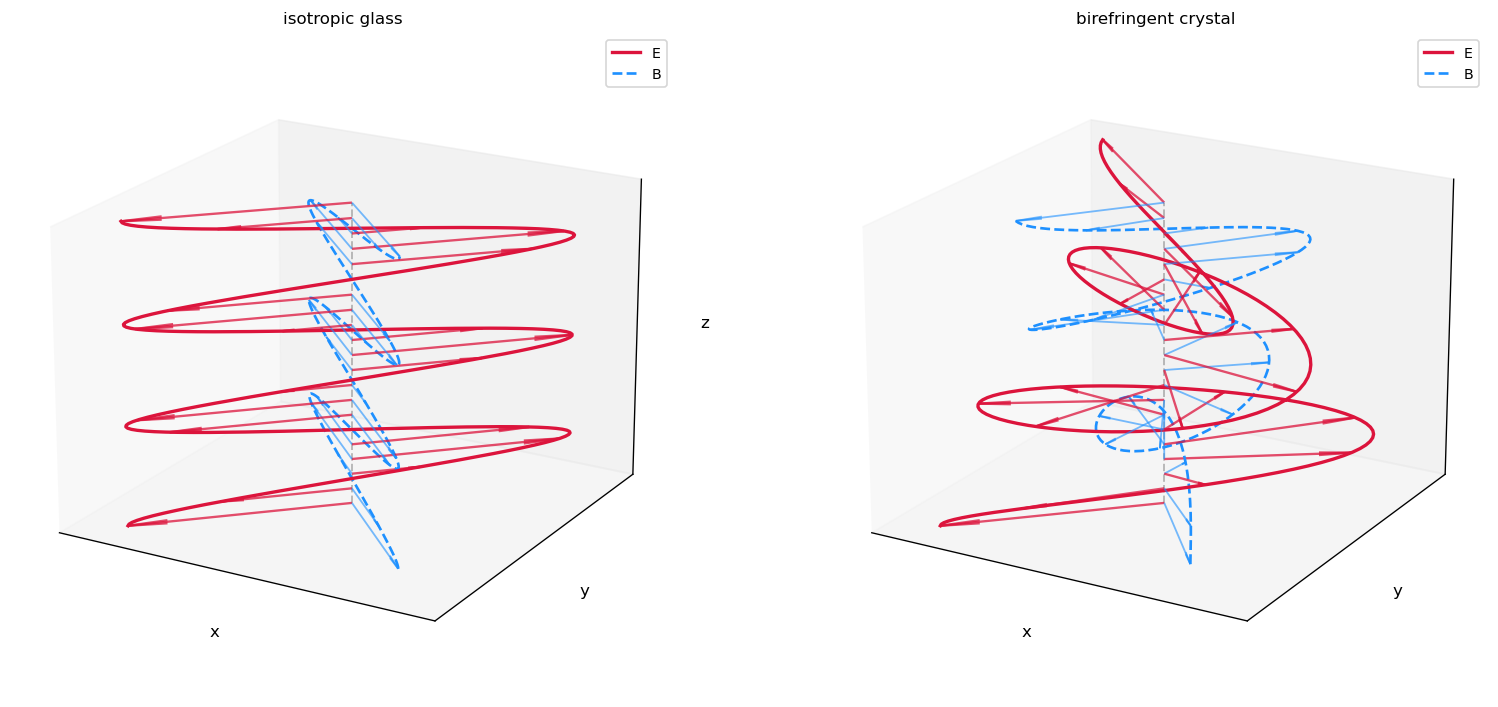

In [5]:
# 1. Locate resonant speeds from singular value dips:
crystal_svals = curves["crystal along z"]
left, mid, right = crystal_svals[:-2], crystal_svals[1:-1], crystal_svals[2:]
is_resonance_dip = (mid <= left) & (mid <= right) & (mid < 2e-3)
resonant_speeds = speeds[1:-1][is_resonance_dip]
v_slow, v_fast = float(resonant_speeds[0]), float(resonant_speeds[1])

# 2. Extract physical transverse polarization vectors for each mode:
#    Compile the wave map W_k at each resonant frequency
#    and unpack the SVD nullspace to obtain the physical polarization eigenmode:
k_slow = v_slow * t + z
wave_slow = k_slow.commutator(crystal(k_slow.wedge(Spatial)))
u_slow, s_slow, vh_slow = wave_slow.svd()
pol_slow = vh_slow[-1]

k_fast = v_fast * t + z
wave_fast = k_fast.commutator(crystal(k_fast.wedge(Spatial)))
u_fast, s_fast, vh_fast = wave_fast.svd()
pol_fast = vh_fast[-1]

# 3D traveling wave comparison: Isotropic Glass (invariant) vs Birefringent Crystal (precession)
glass_modes = [(v_slow, pol_slow), (v_slow, pol_fast)]
crystal_modes = [(v_slow, pol_slow), (v_fast, pol_fast)]
fig = render.draw_wave_comparison_figure(glass_modes, crystal_modes)
plt.show()

## 4. 2D Directional Anisotropy: Polar Fresnel Wave Surfaces

Light does not only travel along $\hat{\mathbf{z}}$. Sweeping the wavevector $\mathbf{k}(\theta) = \sin\theta \mathbf{x} + \cos\theta \mathbf{z}$ across all angles in the $xz$-plane generates the classical **Fresnel wave normal surface** $v(\theta)$.
In an anisotropic crystal, the surface decomposes into two nested sheets: an ordinary circle (isotropic) and an extraordinary ellipse touching at the optic axis.


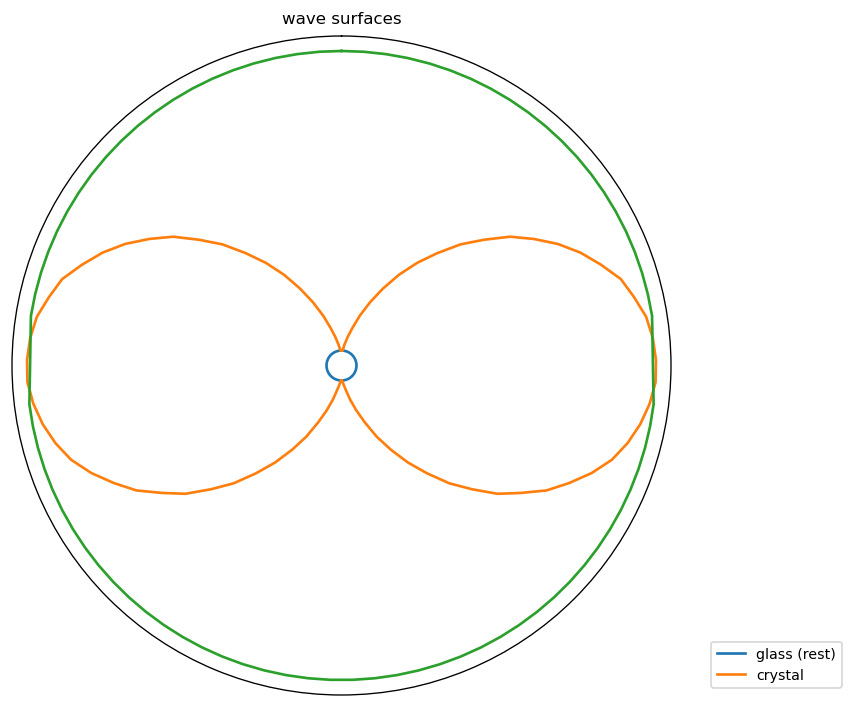

In [6]:
# 1. Sweep propagation angles and trial phase speeds:
angles = np.linspace(0, 2 * np.pi, 90)
sweep_speeds = np.linspace(0.4, 1.0, 601)
k_dirs = np.sin(angles) * x + np.cos(angles) * z                              # [n_angles] Vector

# 2. Vectorized 2D spacetime wavevectors across speeds and angles:
k_grid = sweep_speeds[:, None] * t + k_dirs[None, :]                          # [n_speeds, n_angles] Vector

# 3. Evaluate wave maps across the grid in a single broadcasted pass:
w_glass = k_grid.commutator(glass(k_grid.wedge(Spatial)))
w_crystal = k_grid.commutator(crystal(k_grid.wedge(Spatial)))

# Plot 4: Polar Fresnel normal wave surfaces v(theta) in the xz-plane
fig = render.draw_fresnel_surface_figure(
    angles,
    {
        "glass (rest)": w_glass.svdvals()[..., -1],
        "crystal": w_crystal.svdvals()[..., -1],
    },
    speeds=sweep_speeds,
)
plt.show()

## 5. Spacetime Dynamics: Relativistic Boost & Fresnel Drag

In Spacetime Algebra, setting a medium in motion at speed $\beta$ requires no coordinate shuffling: we simply conjugate the rest constitutive extensor by a Lorentz boost rotor:
$$\chi_{\text{moving}} = L \gg \chi(L \ll \mathcal{B}), \quad L = \exp\left(\tfrac{1}{2} \zeta \mathbf{z} \wedge t\right)$$

The moving medium drags light (Fizeau effect). In the plot below, we compare:
- **Markers (Extensor Eigensolve)**: Numerical roots of the wave condition $k \cdot \chi_{\text{moving}}(k \wedge a) = 0$ computed directly from the boosted constitutive map in NumGA.
- **Solid Lines (Einstein Velocity Addition)**: The exact relativistic addition $v = \frac{c/n \pm \beta}{1 \pm \beta/n}$. The extensor eigensolve matches this exact formula to machine precision.
- **Dashed Lines (Fresnel 1st-Order Drag)**: Fizeau's historical 1851 linear approximation $v \approx \frac{c}{n} \pm \beta(1 - 1/n^2)$, which deviates noticeably at relativistic velocities $|\beta| > 0.3$.


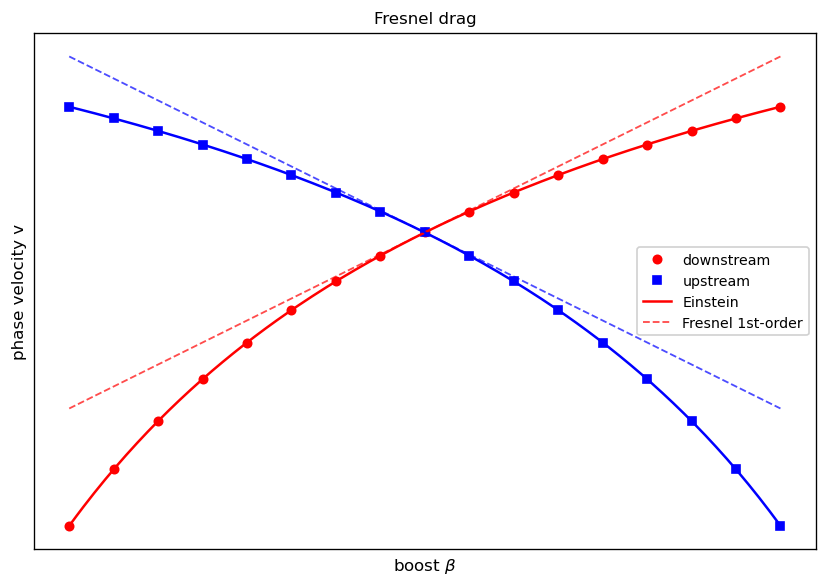

In [7]:
# 1. Sweep medium boost velocity beta in (-0.6, 0.6):
betas = np.linspace(-0.6, 0.6, 17)
drag_speeds = np.linspace(0.05, 1.2, 1151)

# 2. Vectorized Lorentz boost rotors and moving media (batched over betas):
#    In GA, a rotor L transforms an element via the sandwich product L x ~L (written L >> x).
#    To transform a linear map T, we pull the input into the moving frame and push the output back:
#      - boost_rotors << Bivector pulls field bivectors into the medium's rest frame (~L B L).
#      - glass(...) applies the rest-frame constitutive map G = chi_rest(F_rest).
#      - boost_rotors >> ... pushes the resulting excitation G back to the laboratory frame.
rapidity = np.arctanh(betas)
boost_rotors = ((z ^ t) * (rapidity / 2.0)).exp()                             # [n_betas] Motor (Lorentz boost)
moving_media = boost_rotors >> glass(boost_rotors << Bivector)                # [n_betas] Extensor: Bivector <- Bivector

# 3. Vectorized dispersion scan across speeds and boost velocities:
k_down = drag_speeds[:, None] * t + z                                         # [n_speeds, 1] Vector
k_up = drag_speeds[:, None] * t - z                                           # [n_speeds, 1] Vector

w_down = k_down.commutator(moving_media(k_down.wedge(Spatial)))               # [n_speeds, n_betas]
w_up = k_up.commutator(moving_media(k_up.wedge(Spatial)))                     # [n_speeds, n_betas]

v_down = drag_speeds[w_down.svdvals()[..., -1].argmin(axis=0)]
v_up = drag_speeds[w_up.svdvals()[..., -1].argmin(axis=0)]

# Plot 5: Relativistic Fresnel drag curves vs. Einstein velocity addition
fig = render.draw_fresnel_drag_figure(betas, v_down, v_up, eps=eps, mu=mu)
plt.show()